#Ejercicio de los Pinguinos Resuelto

A continuacion se realiza un modelo a partir de la base de datos de los pinguinos, que utilice sus caracteristicas fisicas para clasificar las especies


Variable Objetivo: species

##ANALISIS EXPLORATORIO

### 1. Carga y reconocimiento inicial de los datos

En esta primera etapa se realiza la carga del conjunto de datos y una exploración inicial de su estructura.  
El objetivo es comprender cómo están organizadas las variables, identificar los tipos de datos presentes y obtener una visión general del contenido del dataset.

Este reconocimiento inicial permite detectar posibles problemas como valores faltantes, tipos de datos incorrectos o inconsistencias que deberán abordarse en etapas posteriores del análisis.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


#Carga del dataset
df = pd.read_csv('penguins.csv')

print(df.info())

print('\n')

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB
None




,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


###2. Estadisticas Descriptivas
A partir de estas, se logra identificar anomalias entre las variables

In [5]:
# Resumen estadístico de variables numéricas
display(df.describe())
print('\n')

# Conteo de especies para ver si el dataset está balanceado
df['species'].value_counts()

,Unnamed: 0,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,342.000000,342.000000,342.000000,342.000000,344.000000
mean,172.500000,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,99.448479,5.459584,1.974793,14.061714,801.954536,0.818356
min,1.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,86.750000,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,172.500000,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,258.250000,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,344.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


- La columna unnamed no aporta nada al analisis. Se puede eliminar
- Existen datos faltantes dentro de Count
- En las especies hay un desbalance de clases, lo que puede sesgar nuestro modelo. Podria tender a clasificar todo como adelie solo porque es mas frecuente, no podremos usar solamente el Accuracy para evaluar el modelo final y al ser un grupo pequeño, cualquier outlier tendra un impacto mayor en el promedio de esa especie

###3. Analisis Visual

Veremos las diferencias entre las especies

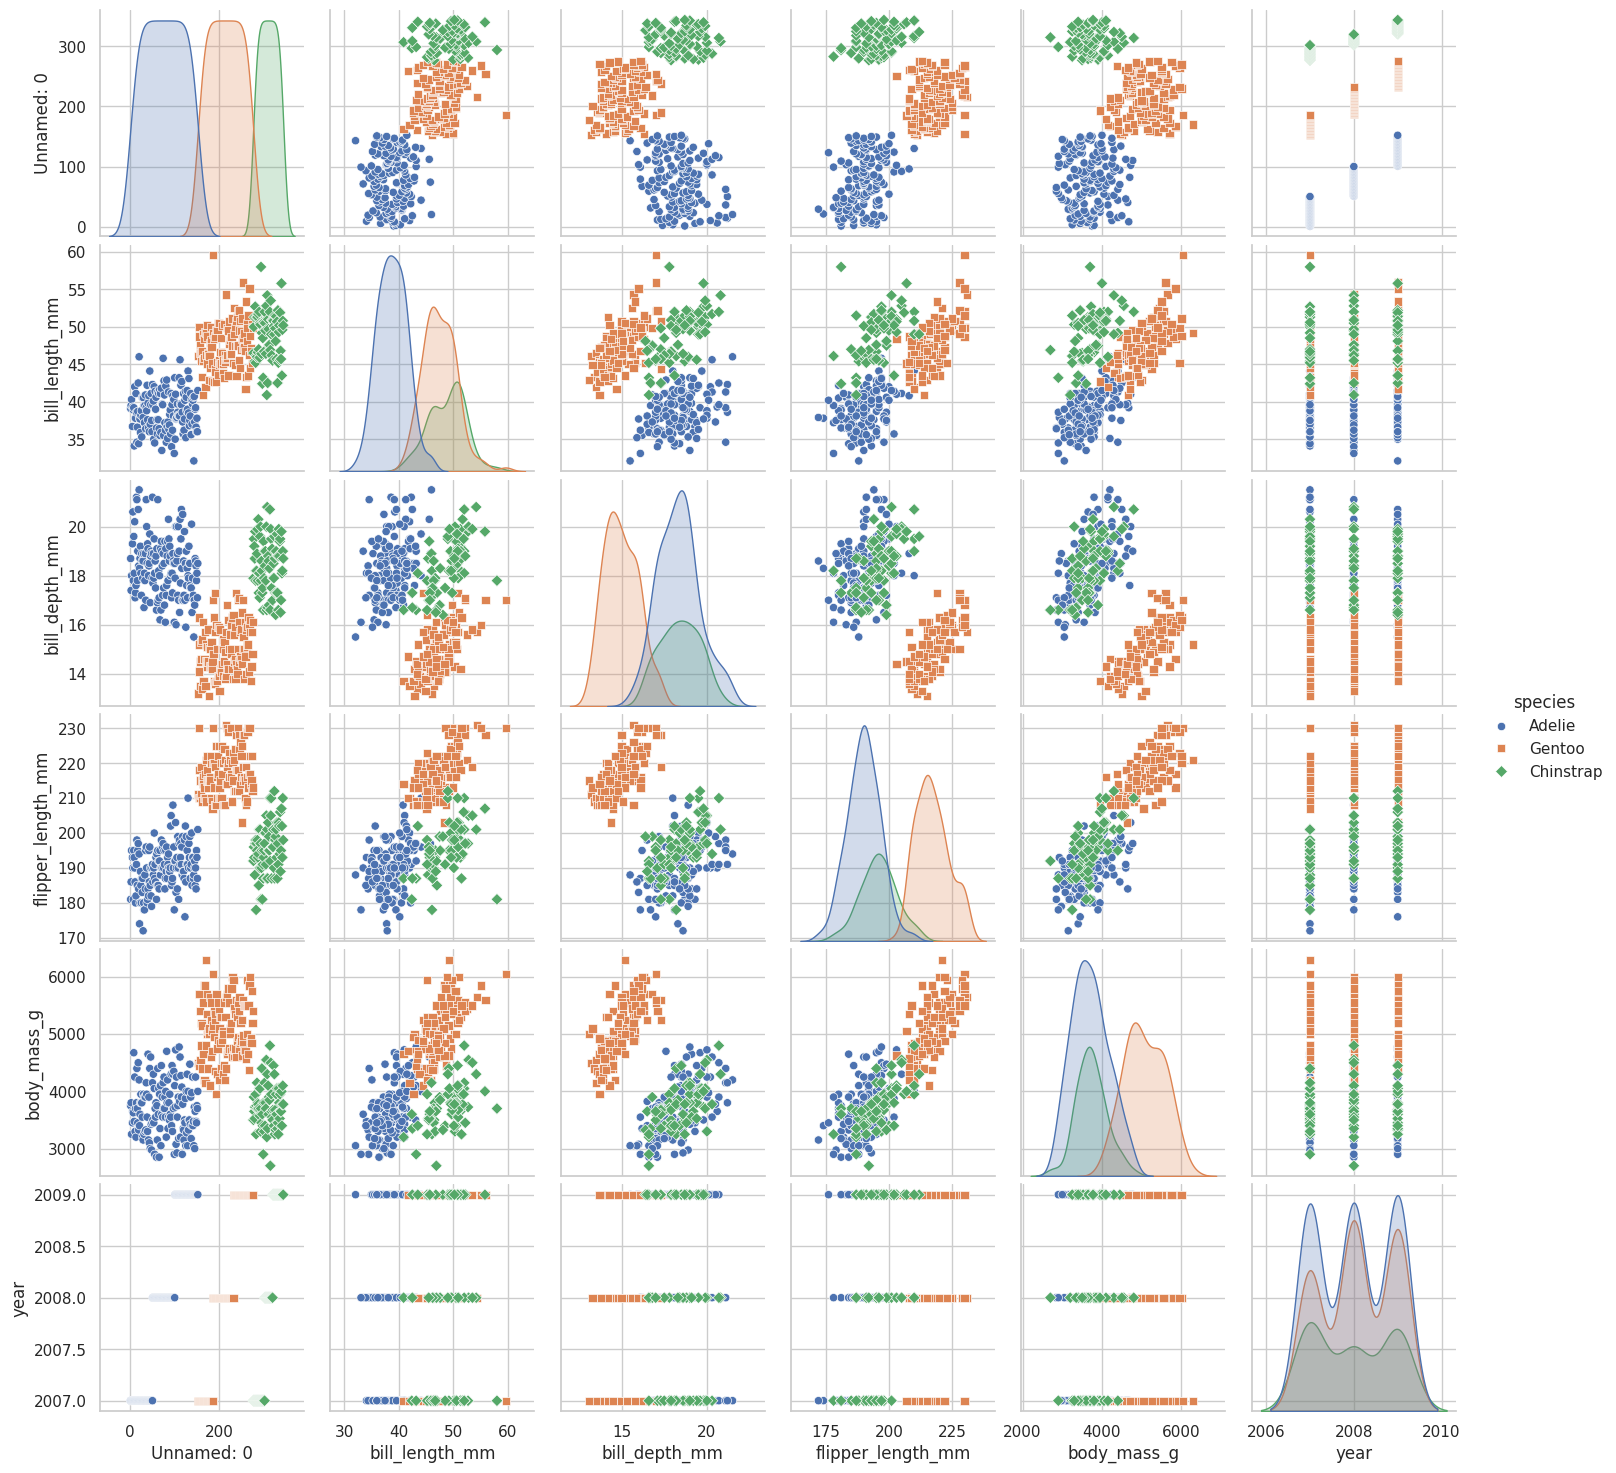

In [6]:
# Configuración estética
sns.set_theme(style="whitegrid")

# Visualizar relaciones entre todas las variables numéricas, coloreando por especie
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.show()

- En la diagonal se logra comprender la distribucion de cada una de las variables, la separacion entre las especies
- Por fuera de la diagonal comprendemos las correlaciones, clusters, separacion entre clases, entre otros


- Entre filpper_lenght vs body_mass, existe correlacion fueremente positiva
- no se observan outliers extremos. En particular, las variables flipper_length_mm y body_mass_g permiten separar de forma clara la especie de las demás. Por otro lado, bill_length_mm y bill_depth_mm contribuyen a diferenciar, aunque existe cierto solapamiento entre estas especies.

###4. Deteccion de Datos Faltantes

Hay que cuantificar los NA antes de limpiar. Ya que debemos decidir si eliminamos las filas con nulos o si imputamos valores

In [7]:
# Conteo exacto
print(df.isnull().sum())

Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


Se van a eliminar, ya que en un dataset pequeño ademas de tener poquitos NA, una mala imputacion puede sesgar el modelo. Solo se perdera eñ 3% de los datos lo que no afectara la capacidad de aprendizaje

###5. Analisis Univariado

Aquí queremos ver cómo se comporta cada variable por sí sola. ¿Tienen una distribución normal (campana de Gauss)? ¿Hay valores extremos?

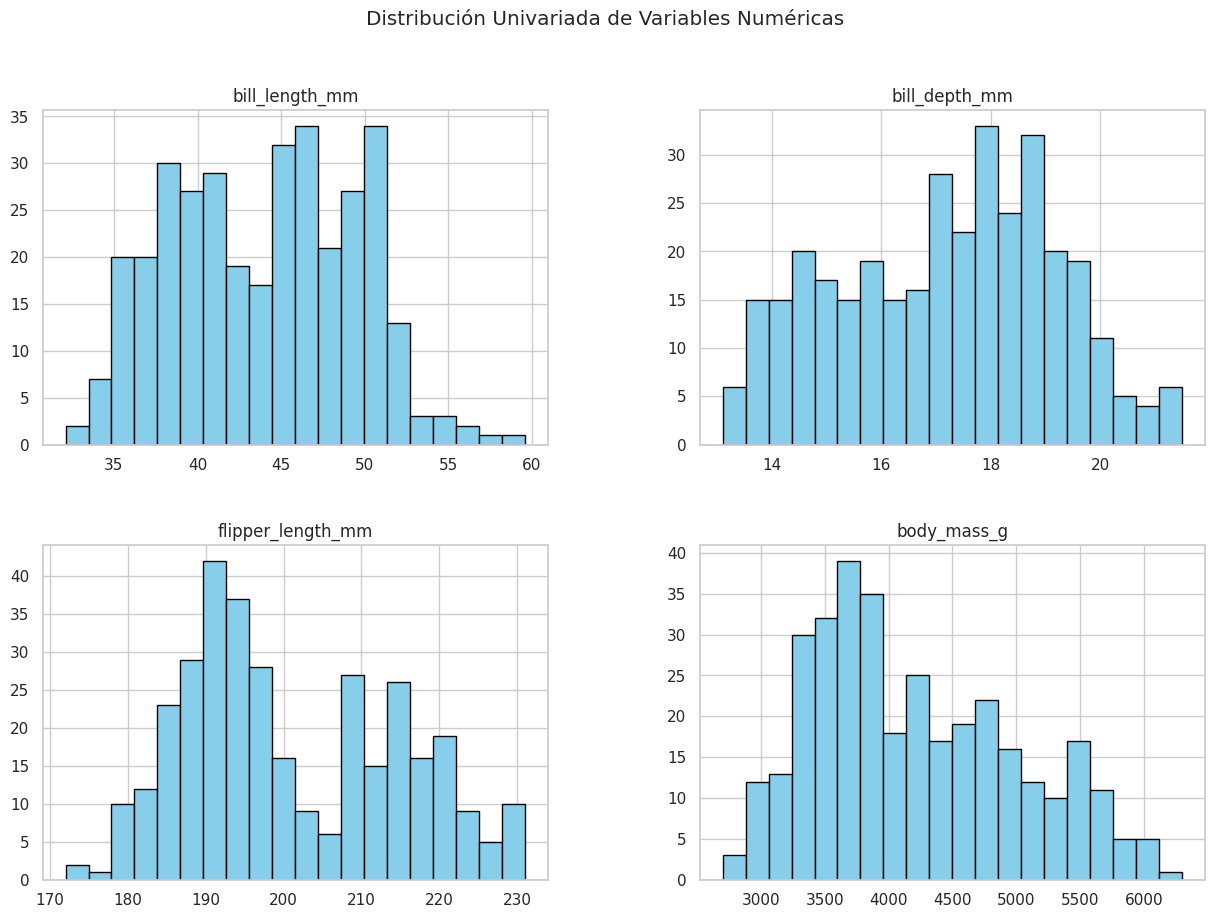

In [8]:
# Histogramas para variables numéricas
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df[features].hist(bins=20, figsize=(15, 10), layout=(2, 2), color='skyblue', edgecolor='black')
plt.suptitle("Distribución Univariada de Variables Numéricas")
plt.show()


A partir de los histogramas se pueden identificar varios patrones importantes:

- Multimodalidad en varias variables

Variables como:

bill_length_mm

flipper_length_mm

body_mass_g

presentan varios picos, lo cual indica la presencia de diferentes especies con características distintas.

- No se observan outliers extremos evidentes

Las distribuciones no muestran valores extremadamente alejados del resto, lo que sugiere que el dataset está relativamente limpio.

De todas formas, esto se confirmará con boxplots.

- Variables potencialmente más discriminantes

Por su distribución, las variables más útiles para diferenciar especies parecen ser:

flipper_length_mm

body_mass_g

bill_length_mm

###Analisis de Proporciones
Queremos ver el "equilibrio" del dataset

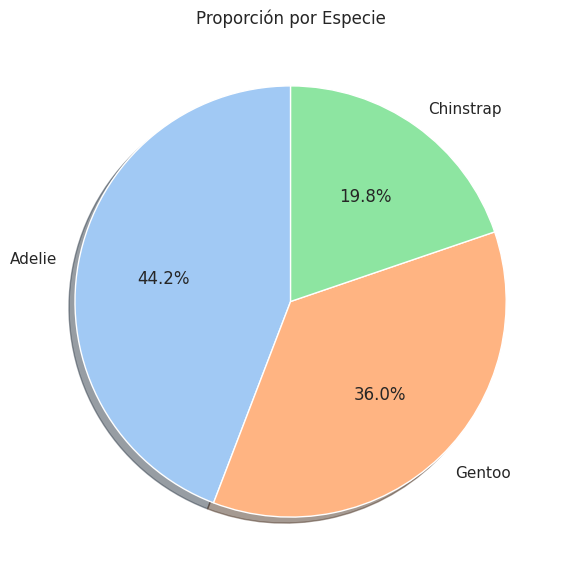

In [9]:
plt.figure(figsize=(7,7))

df['species'].value_counts().plot.pie(
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    colors=sns.color_palette("pastel")
)

plt.title("Proporción por Especie")
plt.ylabel("")  # elimina la etiqueta del eje
plt.show()

Existe un desbalance moderado. En lugar de  usar tecnicas de oversampling(Crear pringuinos artificiales) o undersampling (Borrar pinguinos adelie). Vamos a hacer lo siguiente:

1. Stratified Split (División Estratificada)
Cuando dividamos los datos en "entrenamiento" y "prueba", nos aseguraremos de que esa proporción (44/36/20) se mantenga en ambos grupos. Así el modelo se evalúa con una muestra representativa de la realidad.

2. Usar la Métrica F1-Score
En lugar de preguntar al modelo "¿Cuántos acertaste en total?", le preguntaremos "¿Qué tan bien identificaste a cada especie individualmente?". El F1-Score es el promedio entre la precisión y la sensibilidad, ideal para clases desbalanceadas.

##Limpieza

Eliminaremos la columna unnamed y las filas con nulos para trabajar con datos puros

In [10]:
# Hacemos una copia para no alterar el original por si acaso
df_clean = df.copy()

# 1. Eliminar la columna de índice redundante
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

# 2. Eliminar filas con valores nulos (NaN)
# Como vimos, son pocos datos (aprox 3% del total)
df_clean = df_clean.dropna()

print(f"Registros originales: {len(df)}")
print(f"Registros después de limpieza: {len(df_clean)}")

Registros originales: 344
Registros después de limpieza: 333


##Construccion del Modelo

x(Features): Son las dimensiones fisicas, la ubicacion y el sexo

y(Tarjet): Es la especie

El modelo debe aprender las fronteras de decision para la especie

###1. Transformacion de Categorias


In [11]:


# Aplicamos One-Hot Encoding a 'island' y 'sex'
# 'drop_first=True' es lo que elimina la columna redundante
df_final = pd.get_dummies(df_clean, columns=['island', 'sex'], drop_first=True)

# 3. Convertimos la especie a números (Adelie=0, Chinstrap=1, Gentoo=2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_final['species'] = le.fit_transform(df_final['species'])

# 4. Mostrar el resultado
print("Nuevas columnas después de la conversión:")
print(df_final.columns.tolist())
display(df_final.head())

Nuevas columnas después de la conversión:
['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year', 'island_Dream', 'island_Torgersen', 'sex_male']


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,island_Dream,island_Torgersen,sex_male
0,0,39.1,18.7,181.0,3750.0,2007,False,True,True
1,0,39.5,17.4,186.0,3800.0,2007,False,True,False
2,0,40.3,18.0,195.0,3250.0,2007,False,True,False
4,0,36.7,19.3,193.0,3450.0,2007,False,True,False
5,0,39.3,20.6,190.0,3650.0,2007,False,True,True


Aqui es donde pasamos del lenguaje humano a lenguaje de computadora. Se convierte de plabras a numeros para que el modelo entienda. Usando la tecnica llamada One-Hot Encoding:

Es una tecnica donde al final no hay jerarquia. Solo presencia o ausencia

## Entrenar el Modelo

Vamos a usar un Árbol de Decisión. Es el modelo ideal para empezar porque es muy intuitivo: funciona haciendo preguntas de "Sí o No" (ej. ¿La aleta mide más de 200mm?)

###Dividir los datos (Train/Test Split)
Vamos a separar el 80% de los pingüinos para que el modelo "estudie" y el 20% para evaluarlo.

In [12]:
# Definimos nuestras características (X) y nuestro objetivo (y)
X = df_final.drop(columns=['species'])
y = df_final['species']

# Dividimos: 80% entrenamiento, 20% prueba
# stratify=y asegura que tengamos la misma proporción de especies en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #Aqui se reparten las preguntar y respuestas en dos (Train y Test)

print(f"Pingüinos para entrenamiento: {len(X_train)}")
print(f"Pingüinos para el examen final: {len(X_test)}")

Pingüinos para entrenamiento: 266
Pingüinos para el examen final: 67


###Entrenar el Arbol de Decision
creamos el "cerebro" y le pasamos los datos de entrenamiento.

In [13]:
# Crear el modelo
clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Entrenar el modelo: El modelo lee los datos y empieza a buscar patrones
clf.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


In [ ]:
# Realizar predicciones
y_pred = clf.predict(X_test)

# Ver los resultados
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Adelie       0.91      1.00      0.95        29
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.97      0.95      0.96        67
weighted avg       0.96      0.96      0.96        67



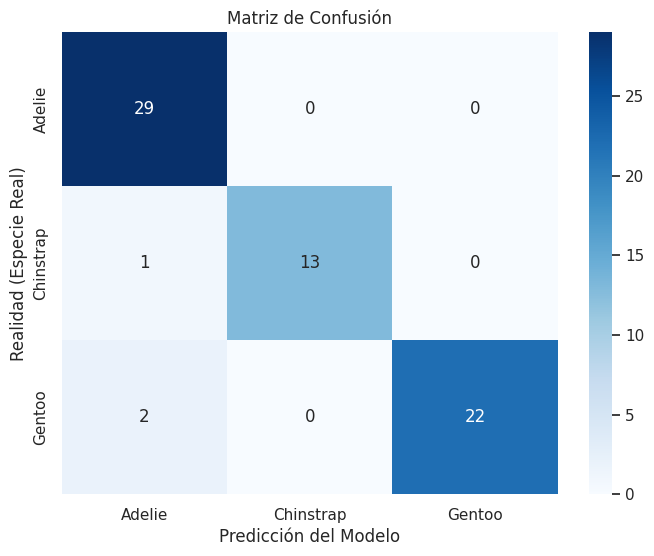

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Especie Real)')
plt.title('Matriz de Confusión')
plt.show()